# 1. Mount Drive & Install Requirements

## Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/users/')

Mounted at /users/


## Install Required Libraries

In [35]:
!pip install pandas numpy matplotlib seaborn plotly scikit-learn
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.3 MB/s eta 0:00:00


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
from sklearn.feature_selection import VarianceThreshold
from docx import Document
from docx.shared import Inches

# 2. Dataset Loading & Basic Structure

# Dataset Path & File Structure Overview

In [6]:
base_path = "/users/"
for root, dirs, files in os.walk(base_path):
    print(root, " --> ", files)

/users/  -->  ['index.html', 'index.html?C=N;O=D', 'index.html?C=M;O=A', 'index.html?C=S;O=A', 'index.html?C=D;O=A', 'index.html?C=N;O=A', 'index.html?C=M;O=D', 'index.html?C=S;O=D', 'index.html?C=D;O=D']
/users/  -->  ['README.pdf', 'index.html', 'index.html?C=N;O=D', 'index.html?C=M;O=A', 'index.html?C=S;O=A', 'index.html?C=D;O=A', 'index.html?C=N;O=A', 'index.html?C=M;O=D', 'index.html?C=S;O=D', 'index.html?C=D;O=D']
/users/  -->  ['all_attack_benign_samples.tar.xz', 'README.pdf', 'index.html', 'index.html?C=N;O=D', 'index.html?C=M;O=A', 'index.html?C=S;O=A', 'index.html?C=D;O=A', 'index.html?C=N;O=A', 'index.html?C=M;O=D', 'index.html?C=S;O=D', 'index.html?C=D;O=D']
/users/  -->  ['attack_samples_10sec.csv', 'attack_samples_7sec.csv.tar.xz', 'attack_samples_9sec.csv.tar.xz', 'attack_samples_5sec.csv.tar.xz', 'attack_samples_1sec.csv.tar.xz', 'attack_samples_10sec.csv.tar.xz', 'attack_samples_3sec.csv.tar.xz', 'attack_samples_6sec.csv.tar.xz', 'attack_samples_8sec.csv.tar.xz', 'atta

## Load Dataset & Show Basic Info

In [8]:
import pandas as pd

processed_file = "/users/"

In [9]:
print("Loading processed dataset...")
df = pd.read_csv(processed_file)
print("Loaded shape:", df.shape, "\n")

Loading processed dataset...
Loaded shape: (16350, 22) 



In [10]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16350 entries, 0 to 16349
Data columns (total 22 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   network_time-delta_avg                16350 non-null  float64
 1   network_time-delta_std_deviation      16350 non-null  float64
 2   network_interval-packets              16350 non-null  float64
 3   network_time-delta_max                16350 non-null  float64
 4   network_packets_all_count             16350 non-null  float64
 5   network_packets_src_count             16350 non-null  float64
 6   network_window-size_std_deviation     16350 non-null  float64
 7   network_packet-size_std_deviation     16350 non-null  float64
 8   network_ttl_avg                       16350 non-null  float64
 9   network_window-size_avg               16350 non-null  float64
 10  network_payload-length_std_deviation  16350 non-null  float64
 11  n

In [11]:
print("\nPreview of Data:")
df.head()


Preview of Data:


,network_time-delta_avg,network_time-delta_std_deviation,network_interval-packets,network_time-delta_max,network_packets_all_count,network_packets_src_count,network_window-size_std_deviation,network_packet-size_std_deviation,network_ttl_avg,network_window-size_avg,...,network_ip-length_std_deviation,network_packet-size_avg,network_ip-length_avg,network_ttl_std_deviation,network_payload-length_avg,network_ip-flags_avg,network_ports_dst_count,network_ip-flags_std_deviation,Binary_Label,Multiclass_Label_Encoded
0,-0.500786,-0.570730,-0.872600,-0.792018,0.895765,1.613875,1.454877,-1.09837,-0.386699,0.798540,...,-0.679642,-0.553468,-0.497947,-0.866616,-0.936641,0.437634,1.700591,1.495450,1,190
1,-0.500826,-0.570849,-0.872691,-0.792018,1.345691,2.141765,1.440477,-1.09837,-0.386699,0.792984,...,-0.681462,-0.553468,-0.498391,-0.866616,-0.936641,0.411035,2.064894,1.498345,1,190
2,-0.500835,-0.570882,-0.872735,-0.793148,1.475320,2.294231,1.437205,-1.09837,-0.386699,0.791727,...,-0.681859,-0.553468,-0.498485,-0.866616,-0.936641,0.405362,2.068860,1.498834,1,190
3,-0.500835,-0.570875,-0.872735,-0.793148,1.475315,2.286041,1.417347,-1.09837,-0.386699,0.784163,...,-0.684235,-0.553468,-0.499039,-0.866616,-0.936641,0.369013,2.068826,1.500899,1,190
4,-0.500835,-0.570851,-0.872735,-0.781130,1.475326,2.284579,1.413757,-1.09837,-0.386699,0.782799,...,-0.684672,-0.553468,-0.499138,-0.866616,-0.936641,0.363241,2.068713,1.501057,1,190


# 3. DATA QUALITY ANALYSIS

## Missing Value Analysis

In [12]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

,0


## Duplicate Row Analysis

In [13]:
duplicate_count = df.duplicated().sum()
print("Total duplicate rows:", duplicate_count)

Total duplicate rows: 63


# 4. TARGET VARIABLE ANALYSIS

## Attack Class Distribution

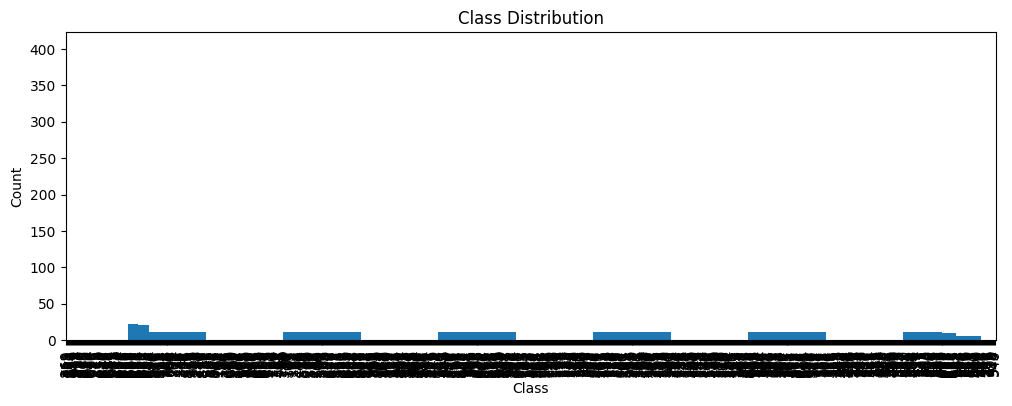

,count
Multiclass_Label_Encoded,
869,403
753,400
928,398
782,395
872,392
...,...
490,5
471,5
470,5


In [14]:
if "Label" in df.columns:
    label_col = "Label"
else:
    label_col = df.columns[-1]  # fallback last column

df[label_col].value_counts().plot(kind="bar", figsize=(12,4), title="Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

df[label_col].value_counts()

## Attack Type Breakdown (Percentage)

In [15]:
(df[label_col].value_counts(normalize=True) * 100).round(2)

,proportion
Multiclass_Label_Encoded,
869,2.46
753,2.45
928,2.43
782,2.42
872,2.40
...,...
490,0.03
471,0.03
470,0.03


# 5. STATISTICAL & FEATURE ANALYSIS

## Numerical Feature Summary

In [16]:
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
network_time-delta_avg,16350.0,1.112532e-16,1.000031,-0.501931,-0.495868,-0.428289,-0.069203,16.035394
network_time-delta_std_deviation,16350.0,-8.343988e-17,1.000031,-0.575442,-0.562178,-0.420265,0.006574,9.761984
network_interval-packets,16350.0,0.000000e+00,1.000031,-0.875673,-0.856766,-0.301541,0.571056,3.139717
network_time-delta_max,16350.0,-2.781329e-17,1.000031,-0.801683,-0.769969,-0.350649,0.352107,6.098930
network_packets_all_count,16350.0,2.781329e-16,1.000031,-2.231676,-0.695001,-0.105736,0.911752,1.475335
network_packets_src_count,16350.0,1.946931e-16,1.000031,-1.692268,-0.875440,-0.005090,0.738270,2.444323
network_window-size_std_deviation,16350.0,-2.781329e-17,1.000031,-0.864004,-0.854542,-0.575550,1.106303,1.777757
network_packet-size_std_deviation,16350.0,9.039320e-17,1.000031,-1.098370,-0.956076,-0.214957,0.860473,1.985241
network_ttl_avg,16350.0,8.343988e-17,1.000031,-6.425674,-0.386699,-0.363703,0.809334,1.596386
network_window-size_avg,16350.0,8.343988e-17,1.000031,-2.084476,-0.243984,0.292869,0.784873,1.186487


## Correlation Heatmap

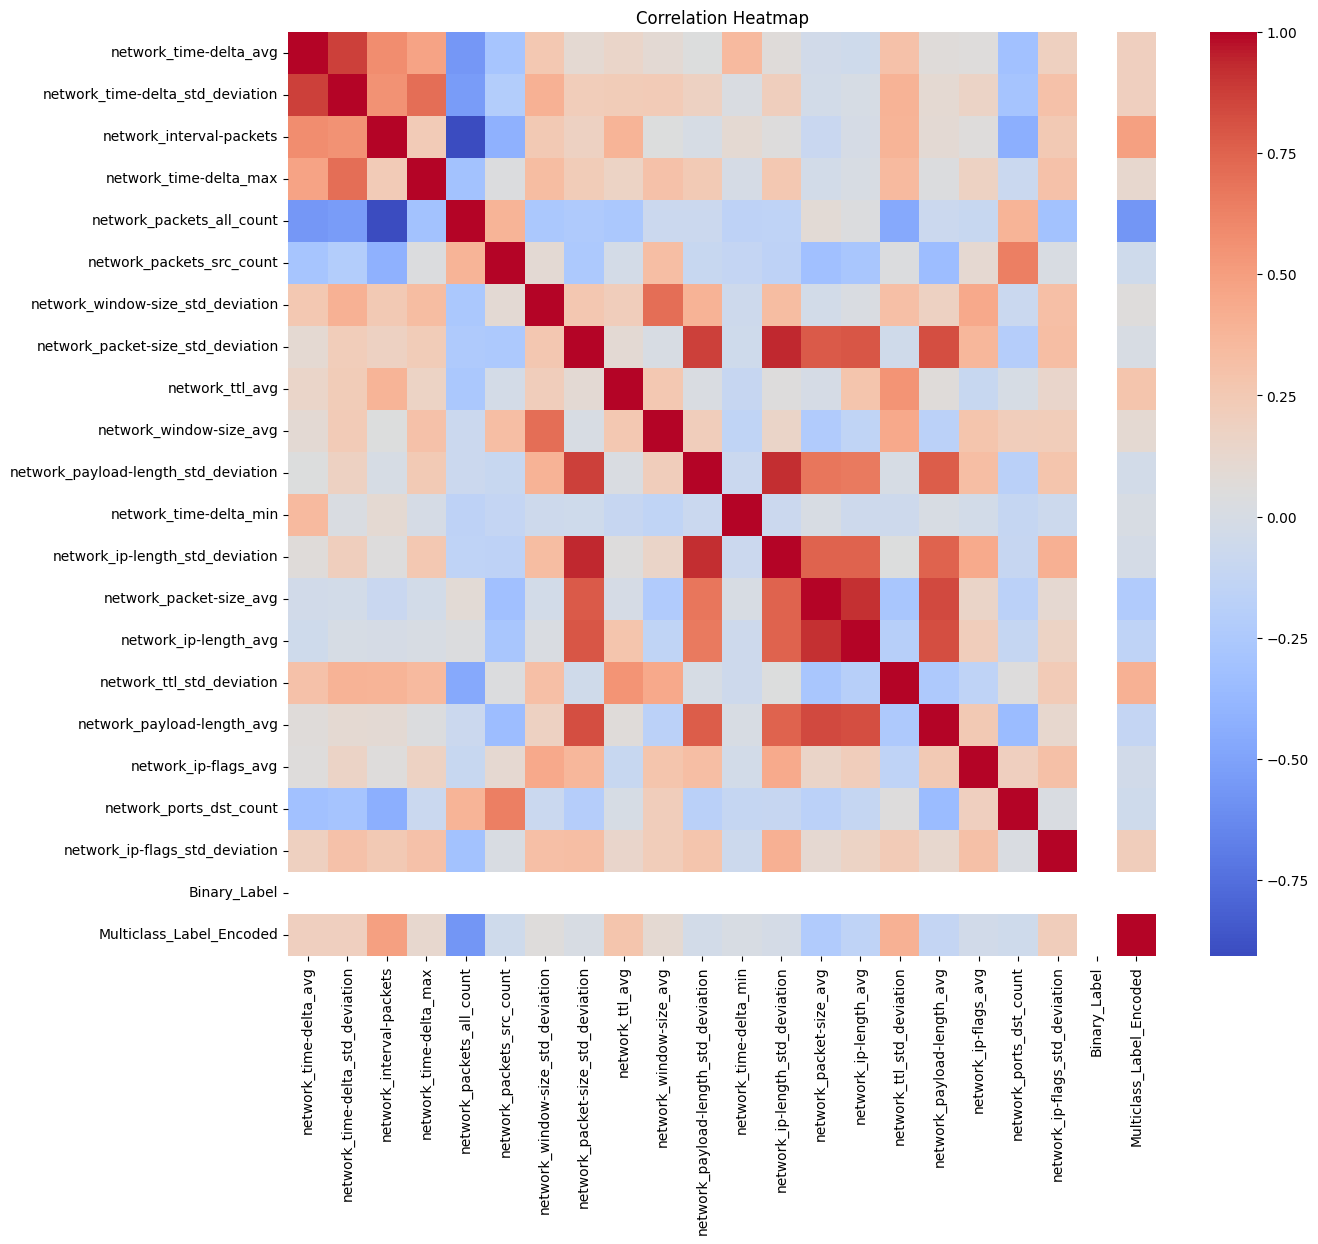

In [17]:
plt.figure(figsize=(14,12))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Feature Variance Check

In [19]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

selector = VarianceThreshold(threshold=0.0)
selector.fit(numeric_df)

constant_features = numeric_df.columns[selector.get_support() == False]

print("Constant / Zero-Variance Features:")
list(constant_features)

Constant / Zero-Variance Features:


['Binary_Label']

# 6. Network Traffic Behavior Analysis

## Packet Size Distribution

In [20]:
packet_cols = [c for c in df.columns if
               "packet" in c.lower() or
               "pkt" in c.lower() or
               "size" in c.lower() or
               "bytes" in c.lower()]

print("Detected Packet-Size Features:", packet_cols)

Detected Packet-Size Features: ['network_interval-packets', 'network_packets_all_count', 'network_packets_src_count', 'network_window-size_std_deviation', 'network_packet-size_std_deviation', 'network_window-size_avg', 'network_packet-size_avg']


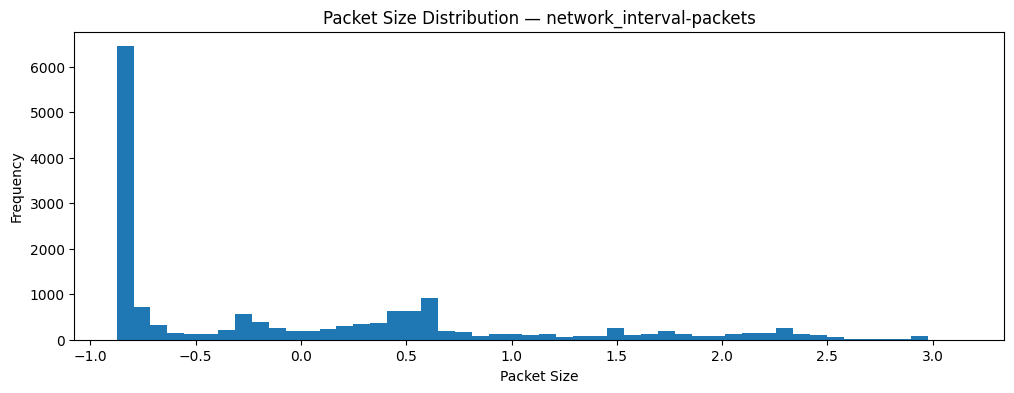

In [21]:
if len(packet_cols) == 0:
    print("❌ No packet-size features found.")
else:
    col = packet_cols[0]
    df[col].plot(kind="hist", bins=50, figsize=(12,4))
    plt.title(f"Packet Size Distribution — {col}")
    plt.xlabel("Packet Size")
    plt.ylabel("Frequency")
    plt.show()

## Flow Duration Distribution

In [22]:
duration_cols = [c for c in df.columns if
                 "duration" in c.lower() or
                 "flowtime" in c.lower() or
                 "flow_time" in c.lower() or
                 "flow_duration" in c.lower()]

print("Detected Duration Features:", duration_cols)

Detected Duration Features: []


## Protocol Distribution

In [24]:
protocol_cols = [c for c in df.columns if
                 "protocol" in c.lower() or
                 "proto" in c.lower()]

print("Detected Protocol Columns:", protocol_cols)

Detected Protocol Columns: []


# 7. TIME-BASED ANALYSIS

## Traffic Volume Over Time

In [25]:
time_cols = [c for c in df.columns if
             "time" in c.lower() or
             "timestamp" in c.lower() or
             "date" in c.lower()]

print("Detected Time Columns:", time_cols)

Detected Time Columns: ['network_time-delta_avg', 'network_time-delta_std_deviation', 'network_time-delta_max', 'network_time-delta_min']


/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


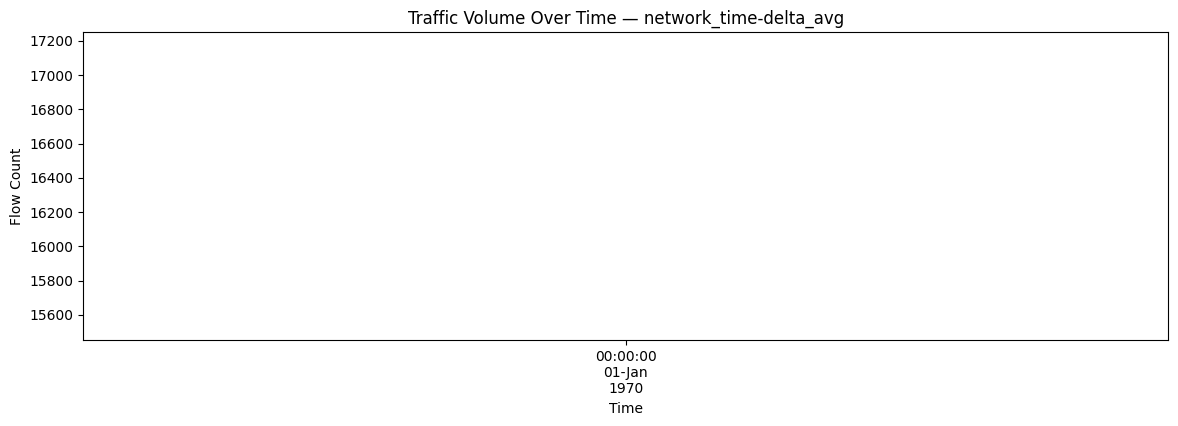

In [26]:
if len(time_cols) == 0:
    print("❌ No timestamp column found in dataset.")
else:
    time_col = time_cols[0]

    # Convert to datetime
    df_time = df.copy()
    df_time[time_col] = pd.to_datetime(df_time[time_col], errors="coerce")

    # Remove invalid timestamps
    df_time = df_time.dropna(subset=[time_col])

    # Resample at 1-minute intervals
    traffic_per_min = df_time.set_index(time_col).resample("1min").size()

    plt.figure(figsize=(14,4))
    traffic_per_min.plot()
    plt.title(f"Traffic Volume Over Time — {time_col}")
    plt.xlabel("Time")
    plt.ylabel("Flow Count")
    plt.show()

    traffic_per_min.head()

# Attack Frequency Over Time

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


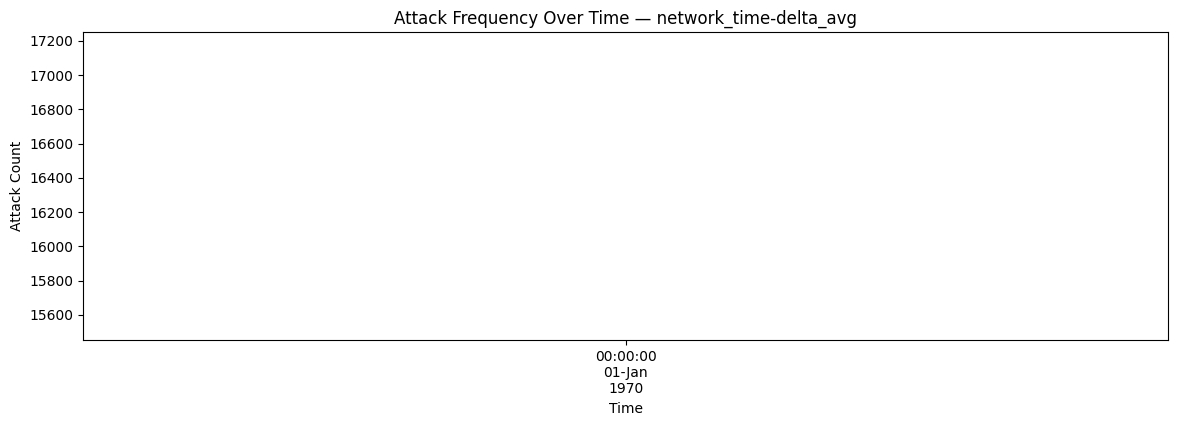

In [27]:
if "Label" in df.columns:
    label_col = "Label"
else:
    label_col = df.columns[-1]

if len(time_cols) == 0:
    print("❌ Time column missing. Cannot compute attack frequency.")
else:
    time_col = time_cols[0]

    df_attack = df.copy()
    df_attack[time_col] = pd.to_datetime(df_attack[time_col], errors="coerce")
    df_attack = df_attack.dropna(subset=[time_col])

    # Filter attacks (non-normal traffic)
    attack_df = df_attack[df_attack[label_col] != "Normal"]

    # Resample at 1 minute
    attacks_per_min = attack_df.set_index(time_col).resample("1min").size()

    plt.figure(figsize=(14,4))
    attacks_per_min.plot(color="red")
    plt.title(f"Attack Frequency Over Time — {time_col}")
    plt.xlabel("Time")
    plt.ylabel("Attack Count")
    plt.show()

    attacks_per_min.head()

# 8. LABEL ENCODING & PREPROCESSING READINESS

## Categorical Feature Check

In [28]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Categorical Columns Detected:")
cat_cols

Categorical Columns Detected:


[]

In [29]:
numeric_like = []

for col in cat_cols:
    try:
        df[col].astype(float)
        numeric_like.append(col)
    except:
        pass

print("Object Columns That Are Actually Numeric:", numeric_like)

Object Columns That Are Actually Numeric: []


## Preprocessing Summary Checklist

In [30]:
print("========== PREPROCESSING SUMMARY ==========\n")

print(f"Total Features: {len(df.columns)}")
print(f"Numeric Features: {len(df.select_dtypes(include=['float64', 'int64']).columns)}")
print(f"Categorical Features: {len(cat_cols)}\n")

# Missing values identified earlier in Section 2
missing_cols = missing[missing > 0].index.tolist()
print("Columns With Missing Values:", missing_cols)

print("\nConstant/Zero-Variance Features:", list(constant_features))

print("\nCategorical Feature List:")
print(cat_cols)

print("\nNEXT STEPS RECOMMENDATION:")
print("""
✔ Encode categorical features (LabelEncoder / OneHotEncoder)
✔ Convert numeric-like object columns to float
✔ Remove or impute missing values
✔ Remove constant columns
✔ Remove highly correlated features (>0.95)
✔ Normalize/standardize numerical features
✔ Handle class imbalance (SMOTE / class weights)
✔ Prepare final training dataset
""")


========== PREPROCESSING SUMMARY ==========

Total Features: 22
Numeric Features: 22
Categorical Features: 0

Columns With Missing Values: []

Constant/Zero-Variance Features: ['Binary_Label']

Categorical Feature List:
[]

NEXT STEPS RECOMMENDATION:

✔ Encode categorical features (LabelEncoder / OneHotEncoder)
✔ Convert numeric-like object columns to float
✔ Remove or impute missing values
✔ Remove constant columns
✔ Remove highly correlated features (>0.95)
✔ Normalize/standardize numerical features
✔ Handle class imbalance (SMOTE / class weights)
✔ Prepare final training dataset



# 9. CROSS-DATASET COMPARISON

In [32]:
print("Total columns:", len(df.columns), "\n")

print("Column Names:")
print(df.columns.tolist())

# Create normalized feature names for comparing across datasets later
normalized_cols = [c.lower().strip() for c in df.columns]
print("\nNormalized Column Set (for cross-dataset alignment):")
print(set(normalized_cols))

Total columns: 22 

Column Names:
['network_time-delta_avg', 'network_time-delta_std_deviation', 'network_interval-packets', 'network_time-delta_max', 'network_packets_all_count', 'network_packets_src_count', 'network_window-size_std_deviation', 'network_packet-size_std_deviation', 'network_ttl_avg', 'network_window-size_avg', 'network_payload-length_std_deviation', 'network_time-delta_min', 'network_ip-length_std_deviation', 'network_packet-size_avg', 'network_ip-length_avg', 'network_ttl_std_deviation', 'network_payload-length_avg', 'network_ip-flags_avg', 'network_ports_dst_count', 'network_ip-flags_std_deviation', 'Binary_Label', 'Multiclass_Label_Encoded']

Normalized Column Set (for cross-dataset alignment):
{'network_ip-length_std_deviation', 'network_time-delta_min', 'network_packets_all_count', 'network_ip-length_avg', 'network_time-delta_max', 'network_payload-length_std_deviation', 'network_interval-packets', 'network_ports_dst_count', 'network_packets_src_count', 'network_p

## Compare Attack Classes Across Datasets

In [33]:
if "Label" in df.columns:
    label_col = "Label"
else:
    label_col = df.columns[-1]

unique_labels = df[label_col].unique()

print("Number of classes:", len(unique_labels))
print("\nAttack/Traffic Classes:")
for cls in unique_labels:
    print(" -", cls)

Number of classes: 936

Attack/Traffic Classes:
 - 190
 - 132
 - 143
 - 162
 - 158
 - 163
 - 273
 - 164
 - 272
 - 275
 - 265
 - 268
 - 153
 - 257
 - 253
 - 161
 - 252
 - 150
 - 262
 - 154
 - 155
 - 250
 - 160
 - 146
 - 156
 - 65
 - 141
 - 255
 - 263
 - 157
 - 266
 - 274
 - 147
 - 140
 - 270
 - 142
 - 144
 - 152
 - 256
 - 267
 - 213
 - 221
 - 220
 - 151
 - 145
 - 251
 - 165
 - 148
 - 254
 - 149
 - 261
 - 260
 - 264
 - 259
 - 258
 - 62
 - 129
 - 271
 - 76
 - 194
 - 218
 - 136
 - 247
 - 134
 - 137
 - 198
 - 139
 - 216
 - 125
 - 206
 - 229
 - 246
 - 86
 - 199
 - 182
 - 130
 - 178
 - 71
 - 210
 - 128
 - 119
 - 215
 - 196
 - 126
 - 242
 - 204
 - 211
 - 200
 - 186
 - 114
 - 80
 - 238
 - 121
 - 138
 - 224
 - 124
 - 231
 - 189
 - 120
 - 217
 - 228
 - 209
 - 240
 - 203
 - 63
 - 202
 - 248
 - 195
 - 85
 - 241
 - 212
 - 214
 - 188
 - 115
 - 237
 - 205
 - 239
 - 131
 - 118
 - 236
 - 116
 - 187
 - 179
 - 64
 - 117
 - 208
 - 183
 - 207
 - 234
 - 222
 - 244
 - 172
 - 230
 - 72
 - 201
 - 245
 - 127
 - 

# 10. FINAL SUMMARY REPORT

## Final EDA Summary Report

In [34]:
print("========== FINAL EDA SUMMARY FOR CIC-IIoT-2025 ==========\n")

# Dataset shape
print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns\n")

# Label column detection
if "Label" in df.columns:
    label_col = "Label"
else:
    label_col = df.columns[-1]
print(f"Label Column Used: {label_col}\n")

# Class distribution
print("---- Class Distribution ----")
print(df[label_col].value_counts(), "\n")

# Class distribution percentage
print("---- Class Distribution (%) ----")
print((df[label_col].value_counts(normalize=True) * 100).round(2), "\n")

# Missing values
print("---- Columns With Missing Values ----")
missing_cols = missing[missing > 0].index.tolist()
print(missing_cols if missing_cols else "No missing values.\n")

# Constant features
print("\n---- Constant / Zero-Variance Features ----")
print(list(constant_features) if len(constant_features) > 0 else "No constant features.\n")

# Categorical features
print("\n---- Categorical Features ----")
print(cat_cols if len(cat_cols) > 0 else "No categorical features.\n")

# Overall numeric summary
num_cols = df.select_dtypes(include=['float64','int64']).columns
print(f"\nTotal Numeric Features: {len(num_cols)}")
print(f"Total Categorical Features: {len(cat_cols)}\n")

print("========== NEXT STEPS RECOMMENDATION ==========\n")
print("""
✔ Drop constant and near-zero variance features
✔ Drop/remove/clean missing value columns if needed
✔ Encode categorical features (LabelEncoder / OneHotEncoder)
✔ Convert numeric-like object columns into float
✔ Remove highly correlated features (>0.95 correlation)
✔ Apply normalization/standardization for numerical features
✔ Handle severe class imbalance using SMOTE or Class Weights
✔ Save cleaned dataset for ML/DL pipelines
✔ Ready for Feature Engineering & Model Training
""")

print("================================================")


========== FINAL EDA SUMMARY FOR CIC-IIoT-2025 ==========

Dataset Shape: 16,350 rows × 22 columns

Label Column Used: Multiclass_Label_Encoded

---- Class Distribution ----
Multiclass_Label_Encoded
869    403
753    400
928    398
782    395
872    392
      ... 
490      5
471      5
470      5
545      5
546      5
Name: count, Length: 936, dtype: int64 

---- Class Distribution (%) ----
Multiclass_Label_Encoded
869    2.46
753    2.45
928    2.43
782    2.42
872    2.40
       ... 
490    0.03
471    0.03
470    0.03
545    0.03
546    0.03
Name: proportion, Length: 936, dtype: float64 

---- Columns With Missing Values ----
No missing values.


---- Constant / Zero-Variance Features ----
['Binary_Label']

---- Categorical Features ----
No categorical features.


Total Numeric Features: 22
Total Categorical Features: 0

========== NEXT STEPS RECOMMENDATION ==========


✔ Drop constant and near-zero variance features
✔ Drop/remove/clean missing value columns if needed
✔ Encode categ

# 11. EDA REPORT

## Save path

In [37]:
save_dir = "/users/"
os.makedirs(save_dir, exist_ok=True)
save_path = f"{save_dir}/CIC_IIoT_2025_FULL_EDA_REPORT.docx"

doc = Document()

## DOCUMENT TITLE

In [38]:
doc.add_heading("CIC-IIoT-2025 - Full Exploratory Data Analysis Report", 0)
doc.add_paragraph("This document contains the complete EDA breakdown including structure, features, statistics, class distribution, missing data, correlation insights, duplicates, and preprocessing readiness.")

## DATASET OVERVIEW

In [39]:
doc.add_heading("1. Dataset Overview", level=1)
doc.add_paragraph(f"• Total Rows: {df.shape[0]:,}")
doc.add_paragraph(f"• Total Columns: {df.shape[1]:,}")
doc.add_paragraph(f"• Label Column: {label_col}")

## CLASS DISTRIBUTION

In [40]:
doc.add_heading("2. Class Distribution", level=1)

class_counts = df[label_col].value_counts()
class_percent = (df[label_col].value_counts(normalize=True) * 100).round(2)

table = doc.add_table(rows=1, cols=3)
hdr = table.rows[0].cells
hdr[0].text = 'Class'
hdr[1].text = 'Count'
hdr[2].text = 'Percentage (%)'

for cls in class_counts.index:
    row_cells = table.add_row().cells
    row_cells[0].text = str(cls)
    row_cells[1].text = str(class_counts[cls])
    row_cells[2].text = str(class_percent[cls])

## DUPLICATE ROW ANALYSIS

In [41]:
doc.add_heading("3. Duplicate Row Analysis", level=1)

dup_total = df.duplicated().sum()
doc.add_paragraph(f"• Total Duplicate Rows: {dup_total}")

## MISSING VALUE ANALYSIS

In [42]:
doc.add_heading("4. Missing Value Analysis", level=1)

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if len(missing_values) > 0:
    table = doc.add_table(rows=1, cols=2)
    hdr = table.rows[0].cells
    hdr[0].text = 'Feature'
    hdr[1].text = 'Missing Count'
    for col, val in missing_values.items():
        row = table.add_row().cells
        row[0].text = col
        row[1].text = str(val)
else:
    doc.add_paragraph("No missing values detected.")

## NUMERICAL FEATURE SUMMARY

In [43]:
doc.add_heading("5. Numerical Feature Statistical Summary", level=1)

num_summary = df.describe().T
table = doc.add_table(rows=1, cols=len(num_summary.columns) + 1)
hdr = table.rows[0].cells
hdr[0].text = 'Feature'

for i, col in enumerate(num_summary.columns):
    hdr[i+1].text = col

for row_idx in num_summary.index:
    row_cells = table.add_row().cells
    row_cells[0].text = str(row_idx)
    for i, col in enumerate(num_summary.columns):
        row_cells[i+1].text = str(round(num_summary.loc[row_idx, col], 4))

## CONSTANT / ZERO VARIANCE FEATURES

In [44]:
doc.add_heading("6. Constant or Zero-Variance Features", level=1)

if len(constant_features) > 0:
    for f in constant_features:
        doc.add_paragraph(f"• {f}")
else:
    doc.add_paragraph("No constant features detected.")

## CATEGORICAL FEATURES

In [45]:
doc.add_heading("7. Categorical Feature List", level=1)

if len(cat_cols) > 0:
    for c in cat_cols:
        doc.add_paragraph(f"• {c}")
else:
    doc.add_paragraph("No categorical features detected.")

## FEATURE CORRELATION INSIGHTS

In [46]:
doc.add_heading("8. Correlation Insights", level=1)
doc.add_paragraph("Correlation heatmap was generated in the notebook. Highly correlated features (>0.95) should be removed to avoid redundancy and multicollinearity.")

## PREPROCESSING READINESS

In [47]:
doc.add_heading("9. Preprocessing Summary", level=1)
doc.add_paragraph("Recommended preprocessing steps:")
doc.add_paragraph("✔ Remove constant features")
doc.add_paragraph("✔ Handle missing values (if any)")
doc.add_paragraph("✔ Encode categorical variables")
doc.add_paragraph("✔ Normalize/standardize numeric features")
doc.add_paragraph("✔ Remove highly correlated features")
doc.add_paragraph("✔ Balance dataset using SMOTE or class weights")
doc.add_paragraph("✔ Create final training dataset")

## FULL DATASET METADATA SNAPSHOT

In [48]:
doc.add_heading("10. Full Dataset Metadata Snapshot", level=1)
doc.add_paragraph("Below is a complete metadata snapshot including column names, dtypes, and unique counts.")

meta_table = doc.add_table(rows=1, cols=3)
hdr = meta_table.rows[0].cells
hdr[0].text = 'Feature'
hdr[1].text = 'Data Type'
hdr[2].text = 'Unique Count'

for col in df.columns:
    row = meta_table.add_row().cells
    row[0].text = col
    row[1].text = str(df[col].dtype)
    row[2].text = str(df[col].nunique())


## SAVE REPORT

In [50]:
doc.save(save_path)
print(f"📄 Report Generated Successfully: {save_path}")

📄 Report Generated Successfully: /users/
